In [6]:
import pandas as pd

In [7]:
df_us = pd.read_csv("../data/processed/openfoodfacts_us_clean.csv", low_memory=False)  

In [8]:
#how many nulls in each column
df_us.isnull().sum()

product_name            9054
categories            164900
countries                  0
nutriscore_score      197482
nutriscore_grade         649
energy-kcal_100g       42367
fat_100g               45268
saturated-fat_100g    101461
carbohydrates_100g     44490
sugars_100g            77216
fiber_100g            130694
proteins_100g          45042
sodium_100g            73076
dtype: int64

In [9]:
#we mainly need nutriscore_grade, so for the 649 nulls, we will see how many of them have a nutriscore so that we can derive the grade. the rest, which have neither, can be dropped
df_us[df_us['nutriscore_grade'].isnull() & df_us['nutriscore_score'].isnull()].shape[0]

649

  ## Missing Value Analysis                                                                                                                                                                                         
                                                                                                                                                                                                                    
  ### Target variable: nutriscore_grade                                                                                                                                                                             
  - 649 rows missing nutriscore_grade                                                                                                                                                                               
  - Checked if nutriscore_score could recover them — all 649 also missing score
  - Decision: drop these rows (0.1% of dataset, negligible impact)  

In [10]:
df_us['nutriscore_grade'].value_counts()

nutriscore_grade
unknown           192653
e                 111261
d                  78565
c                  60300
a                  47866
b                  35992
not-applicable      4180
Name: count, dtype: int64

  ## Class Distribution Analysis                                                                                                                                                                                    
                                          
  ### Dropping non-grade rows                                                                                                                                                                                       
 We will be dropping rows with 'unknown' and 'not-applicable' as that is not a nutriscore grade and rather a placeholder for 'i dont know'. Even for products that don't get a Nutri-Score, our model will not know what to classify it as -Healthy/Moderate/Avoid                                                                                                                                                          
                                                                                                                                                                                                                    
  ### Class imbalance                                                                                                                                                                                               
  The dataset had roughly 3:1 ratio of E to A grades, which risks biasing the model toward unhealthy predictions. It might end up over predicting unhealthy and under predicting healthy.  We could address it as -                                                                                                                                                                                         
    1. Resampling — oversample minority classes or undersample majority                                                                                                                                               
    2. Class weights — tell the model to penalize mistakes on minority classes more                                        
  ### Decision: class weights                                                                                                                                                                                       
 I will be using class weights in place of resampling, as resampling minority would create duplicates or undersampling majority would waste legit data. Class weights would not touch the data and rather it will tell the model 'a mistake on class A costs more than a mistake on class E.'

In [11]:
  df_us[['energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',
         'carbohydrates_100g', 'sugars_100g', 'fiber_100g',                                                                                                                                                         
         'proteins_100g', 'sodium_100g']].describe()   

,energy-kcal_100g,fat_100g,saturated-fat_100g,carbohydrates_100g,sugars_100g,fiber_100g,proteins_100g,sodium_100g
count,489099.000000,486198.000000,430005.000000,486976.000000,454250.000000,400772.000000,486424.000000,458390.000000
mean,313.167616,14.941549,5.665514,36.389145,17.634749,3.310735,9.829673,0.877430
std,470.380935,36.608877,23.720764,59.222606,37.742340,51.105911,27.137397,16.525276
min,0.000000,0.000000,0.000000,0.000000,-1.450000,-44.700000,-12.600000,0.000000
25%,93.000000,0.000000,0.000000,5.460000,1.010000,0.000000,0.790000,0.015000
50%,253.000000,5.880000,1.900000,21.240000,5.000000,1.300000,5.380000,0.208000
75%,400.000000,19.440000,7.140000,57.140000,22.900000,3.600000,12.500000,0.536000
max,58000.000000,4600.000000,12500.000000,6800.000000,2560.000000,29500.000000,9100.000000,3000.000000


Matplotlib is building the font cache; this may take a moment.


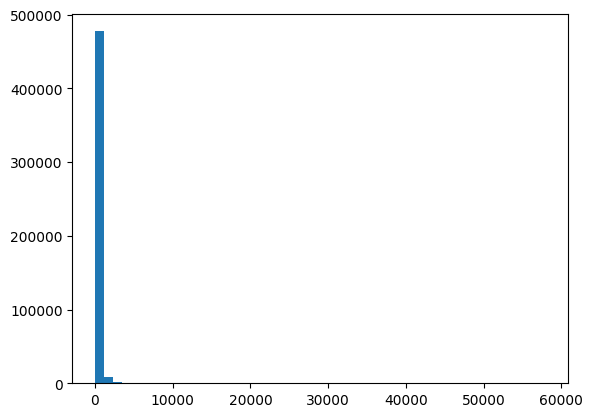

In [13]:
import matplotlib.pyplot as plt

plt.hist(df_us['energy-kcal_100g'], bins=50)
plt.show()

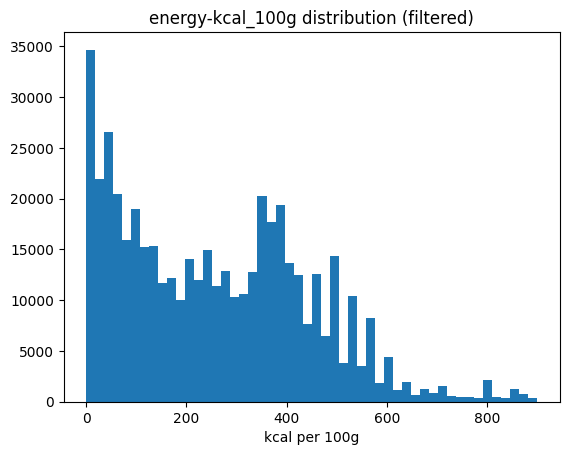

In [14]:
plt.hist(df_us[df_us['energy-kcal_100g'] < 900]['energy-kcal_100g'], bins=50)
plt.title('energy-kcal_100g distribution (filtered)')                                                                                                 
plt.xlabel('kcal per 100g') 
plt.show()

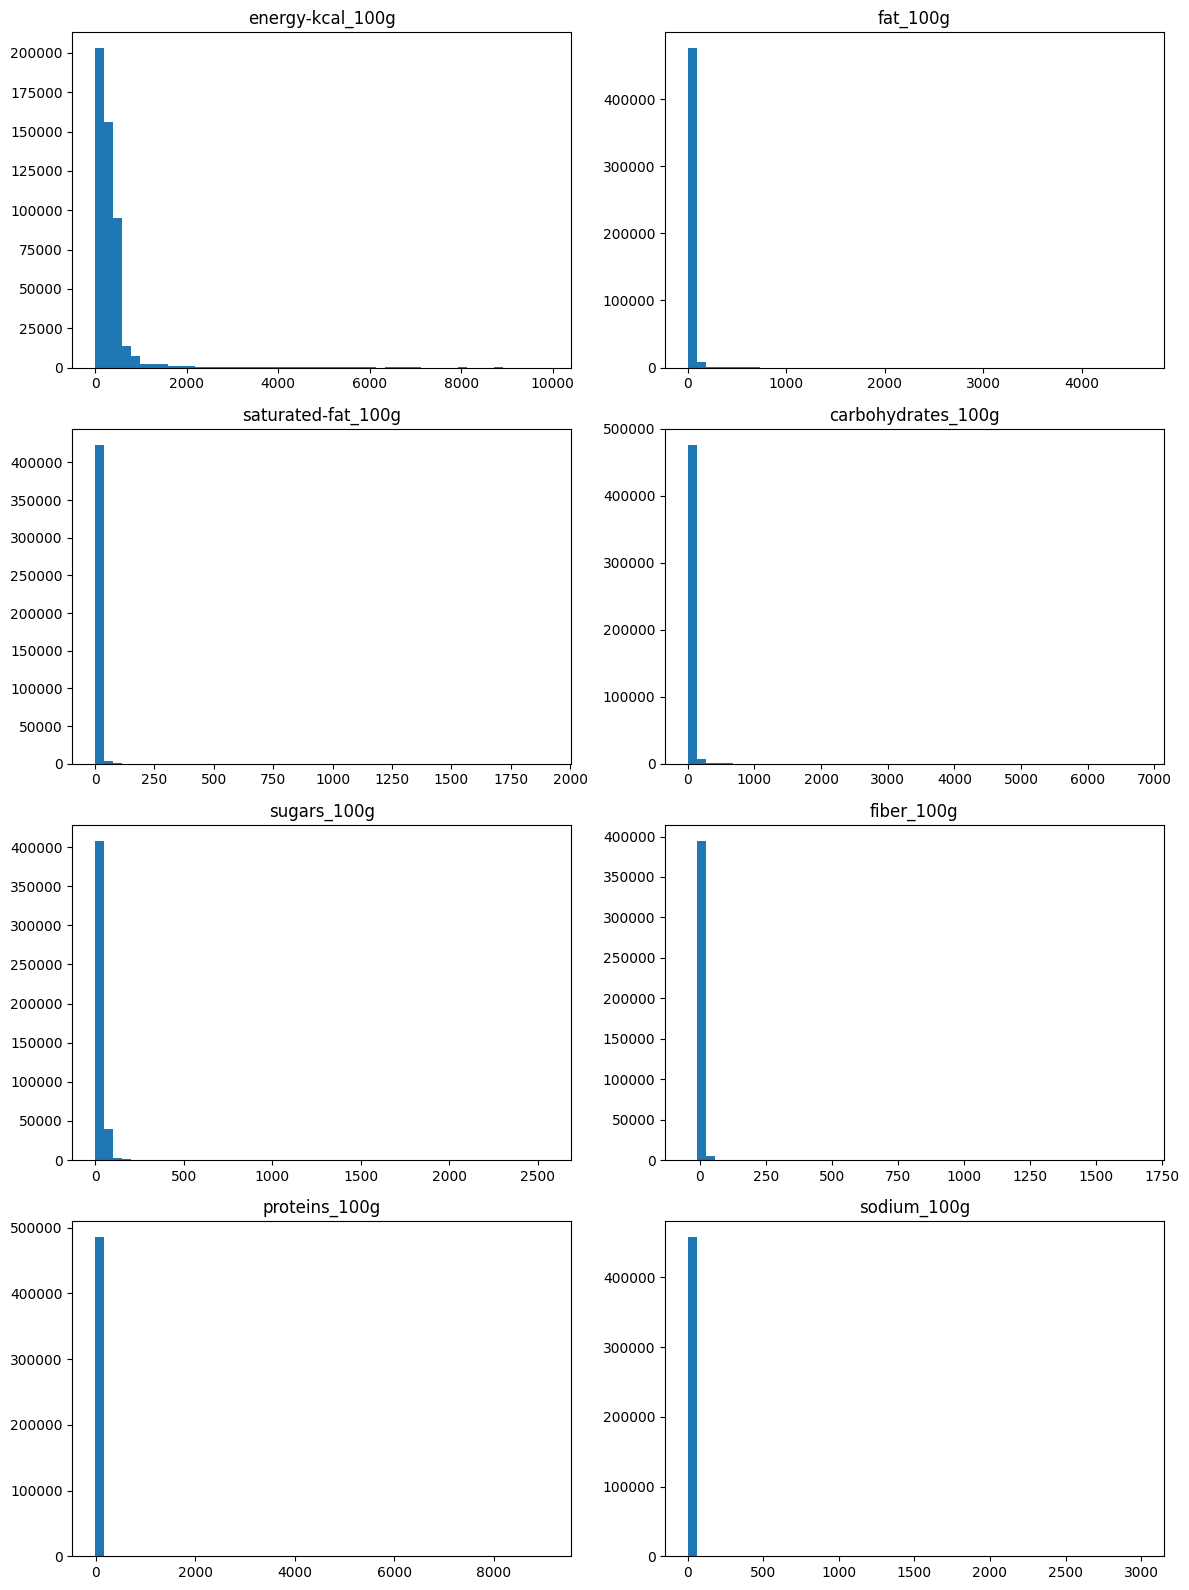

In [15]:
nutrient_cols = ['energy-kcal_100g', 'fat_100g', 'saturated-fat_100g',                                                                                
                   'carbohydrates_100g', 'sugars_100g', 'fiber_100g',                                                                                   
                   'proteins_100g', 'sodium_100g']
fig, axes = plt.subplots(nrows=4, ncols=2, figsize=(12,16))
axes = axes.flatten()

for i, col in enumerate(nutrient_cols):                                                                                                               
    axes[i].hist(df_us[df_us[col] < 10000][col].dropna(), bins=50)
    axes[i].set_title(col)                                                                                                                            
                                          
plt.tight_layout()
plt.show()   

  ## Distribution Analysis                
                                                                                                                                                        
  ### energy-kcal_100g                                                                                                                                  
  - Right-skewed distribution — most foods cluster at lower calories, long tail toward high-calorie foods                                               
  - Extreme outlier at 58,000 kcal (physically impossible — data entry error)                                                                           
  - Will apply log transform in feature engineering step                                                                                                
                                          
  ### Outlier thresholds                                                                                                                                
  - Nutrients per 100g cannot physically exceed 100g                                                                                                    
  - Calories per 100g capped at 900 for real foods                                                                                                      
  - Negative values (found in sugars, fiber, proteins) are data entry errors                                                                            
  - Decision: drop rows with physically impossible values rather than impute — these are not statistical outliers, they are bad data
  - All 8 nutrient columns are right-skewed                                                                                                             
  - All have extreme outliers that are physically impossible                                                                                            
  - All will need either outlier removal or log transform

In [18]:
import missingno as msno

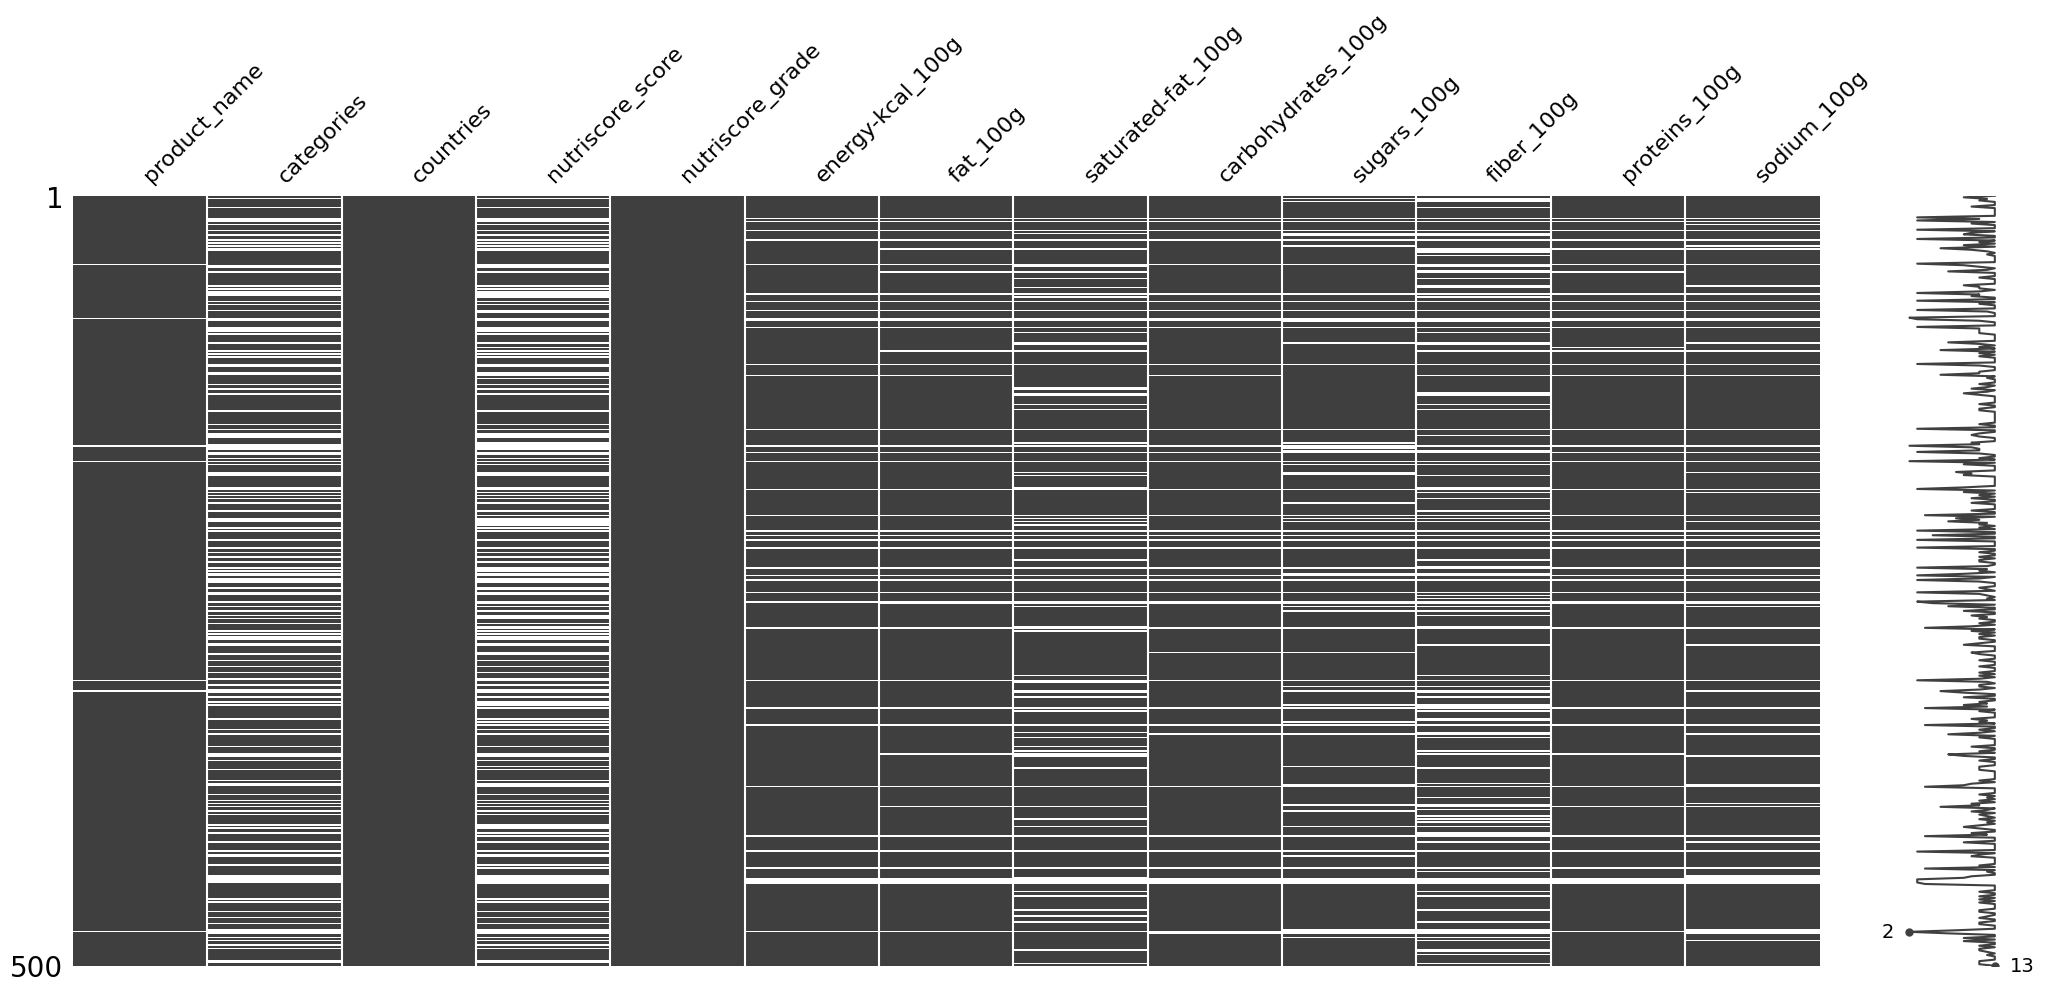

In [19]:
msno.matrix(df_us.sample(500))
plt.show()

## Missing Values
The missing value matrix showed correlated missingness across nutrient columns — the same products were missing multiple 
values. This suggested systematic underreporting rather than random gaps, so I will drop rows missing more than X nutrient columns rather than        imputing.